In [5]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [6]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 6
NumViolon = [1, 4, 5, 9, 11, 13]  # Violons a analyser
DyndB = 90

NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

In [7]:
import sys
if '../scripts' not in sys.path:
    sys.path.insert(0, '../scripts')

import utils_DirViolins as udv
#vertices, faces = udv.load_violin_mesh('../src/Meshes/violin.ply')
#udv.plot_array_matplotlib(XYZm, XYZs, XYZHammerImpact, vertices, faces, NbMics)
#udv.plot_array_threejs(XYZm, XYZs, XYZHammerImpact, vertices, faces, NbMics)


In [8]:
import os

# In this repo layout, swd2 processing modules live under swd2/src
swd2_root_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Outils/swd/swd2")
if swd2_root_dir not in sys.path:
    sys.path.insert(0, swd2_root_dir)

import src.spherical_processing as swd
import src.geotools as geom

Max_Order = 15
CmnFileName = f'./../results/CmnO{Max_Order}_Optimization_Results.npz'
Cmn = np.load(CmnFileName)['Cmn_all']
frq = np.load(CmnFileName)['freqs']
kvect = 2*np.pi*frq/C
frqMax = frq[-1]

In [9]:
# Compute FD (Field Directivity) from SH coefficients

print("Starting Hfd computation...")

# Initialize FD array: (NbViolins, NbMics, NbFrequencies)
Hfd = np.zeros((NbViol, NbMics, len(frq)), dtype=np.complex128)

N_k = len(kvect)
N_SH = int(np.sqrt(Cmn.shape[1]) - 1)
H_origin_to_field = swd.compute_SphericalWavesbasis_origin_to_field(
    XYZm, 
    kvect, 
    N_SH, 
    SH_center=np.array([0,0,0])
    )
# H_origin_to_field: (NbDirs, N_SH_coefficients, N_k)
# Cmn[i,:,:]:        (N_SH_coefficients, N_k)
# FD[i]:             (NbDirs, N_k)
# Contract over the SH axis for each frequency simultaneously.
for i in tqdm(range(NbViol), desc="Violins"):    
    Hfd[i] = np.einsum('dnk,nk->dk', H_origin_to_field, Cmn[i,:,:])

print("Hfd computation complete!")
print(f"Hfd shape: {Hfd.shape}, dtype: {Hfd.dtype}")
print(f"Hfd magnitude range: [{np.abs(Hfd).min():.3e}, {np.abs(Hfd).max():.3e}]")
print(f"Hfd real part range: [{Hfd.real.min():.3e}, {Hfd.real.max():.3e}]")
print(f"Hfd imag part range: [{Hfd.imag.min():.3e}, {Hfd.imag.max():.3e}]")


Starting Hfd computation...


Violins: 100%|██████████| 6/6 [00:01<00:00,  3.48it/s]

Hfd computation complete!
Hfd shape: (6, 256, 2480), dtype: complex128
Hfd magnitude range: [8.157e-06, 9.429e+00]
Hfd real part range: [-6.126e+00, 9.010e+00]
Hfd imag part range: [-8.459e+00, 7.460e+00]


In [10]:
#X_imp, duration_s = udv.build_causal_excitation(frq)
duration_s = 0.1

In [11]:
Fs_RI = 50_000
RIs = np.load('./../results/ViolinsFRFsAndRIs.npz')['RIhm']
t_RIs = np.arange(RIs.shape[1]) / Fs_RI

Selected microphone indices, distances, and directions:
  point 0: mic 244  r = 33.1 cm  az =  -29.8 deg  el =  -67.2 deg  u = (+0.336, -0.192, -0.922)
  point 1: mic 197  r = 58.5 cm  az =  -90.0 deg  el =   65.6 deg  u = (+0.000, -0.412, +0.911)
  point 2: mic  62  r = 66.4 cm  az = -141.2 deg  el =  -27.5 deg  u = (-0.691, -0.557, -0.461)
  point 3: mic 112  r = 73.2 cm  az = -152.3 deg  el =    4.0 deg  u = (-0.884, -0.463, +0.069)
  point 4: mic  15  r = 94.7 cm  az =  135.1 deg  el =   29.0 deg  u = (-0.619, +0.617, +0.485)


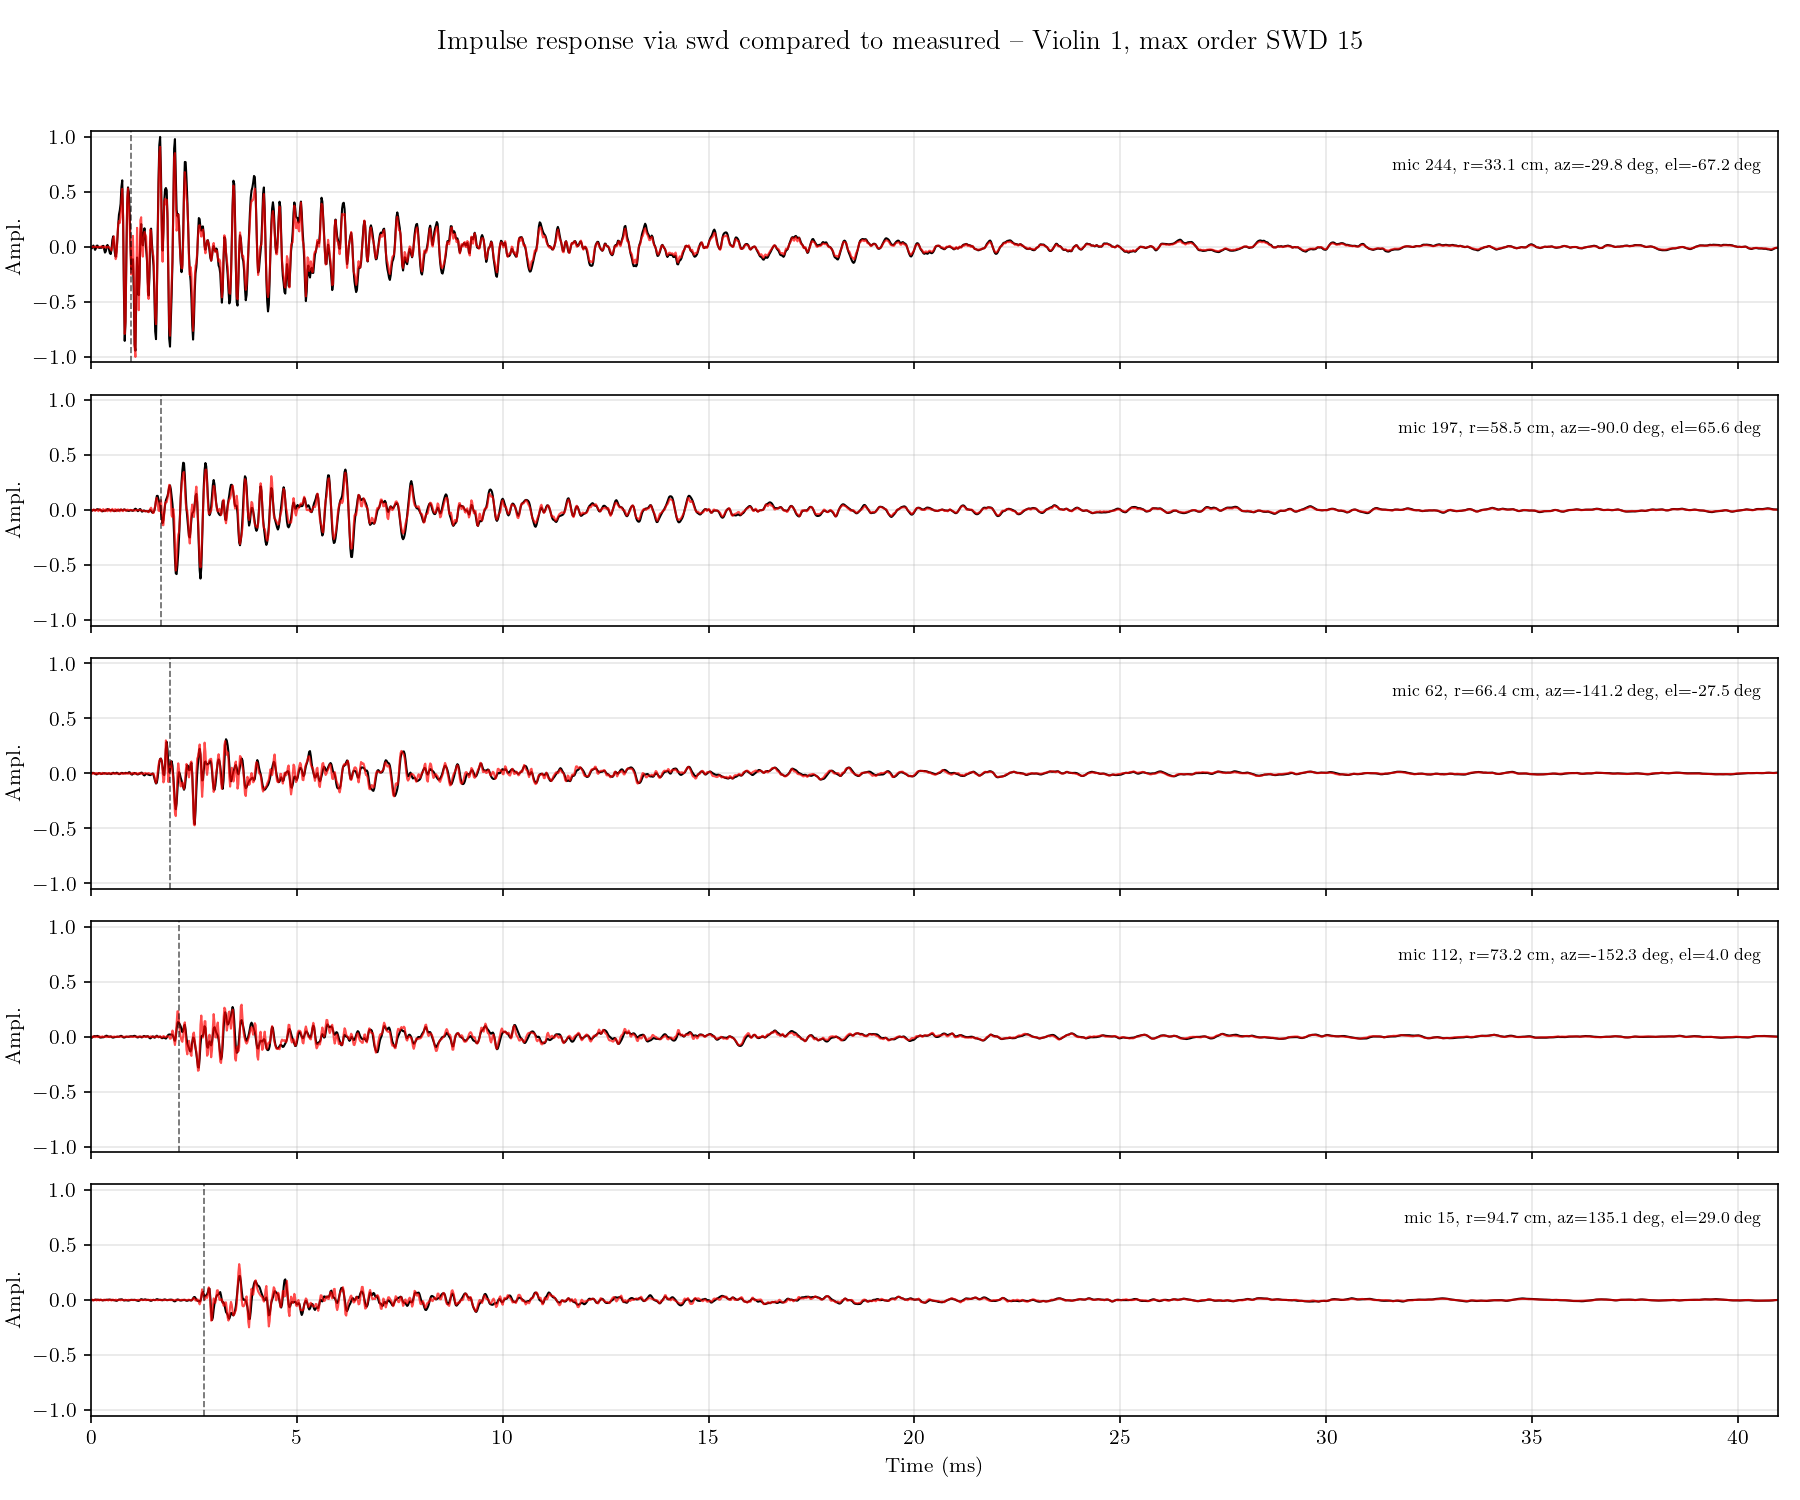

In [12]:
# Impulse response at 5 microphone positions (nearest to farthest from origin)
# Synthesis: y(t) = 2 Re( sum_k FD[v,d,k]*X_imp[k] * exp(j2pi*frq[k]*t) ) * df

viol_idx = 0  # violin to analyse (change 0..NbViol-1 as needed)

# --- select 5 mics by distance from origin ---
r_mics   = np.linalg.norm(XYZm, axis=1)          # (256,)
sorted_idx = np.argsort(r_mics)
pick_pos   = np.linspace(0, len(sorted_idx) - 1, 5, dtype=int)
sel_idx    = sorted_idx[pick_pos]
r_sel      = r_mics[sel_idx]

# Direction of selected microphones (from origin)
dirs_sel = XYZm[sel_idx] / (r_sel[:, None] + 1e-30)
az_deg = np.degrees(np.arctan2(dirs_sel[:, 1], dirs_sel[:, 0]))
el_deg = np.degrees(np.arctan2(dirs_sel[:, 2], np.linalg.norm(dirs_sel[:, :2], axis=1)))

print("Selected microphone indices, distances, and directions:")
for k, (idx, r) in enumerate(zip(sel_idx, r_sel)):
    ux, uy, uz = dirs_sel[k]
    print(
        f"  point {k}: mic {idx:3d}  r = {r*100:.1f} cm  "
        f"az = {az_deg[k]:6.1f} deg  el = {el_deg[k]:6.1f} deg  "
        f"u = ({ux:+.3f}, {uy:+.3f}, {uz:+.3f})"
    )

# --- frequency-domain output ---
df    = frq[1] - frq[0]                      # 5 Hz
H_sel = Hfd[viol_idx][sel_idx, :]            # (5, Nk)

# --- time synthesis at 50 kHz (> 2 * frq_max = 25 kHz) ---
fs_out = 50_000
t_out  = np.arange(0, duration_s, 1.0 / fs_out)              # (2000,)
phase  = np.exp(1j * 2 * np.pi * frq[:, None] * t_out[None, :])  # (Nk, Nt_out)
h_td   = 2.0 * np.real(H_sel @ phase) * df                   # (5, Nt_out)

# --- normalise to peak of nearest mic so relative levels are preserved ---
norm_ref  = np.max(np.abs(h_td[0])) + 1e-30
h_td_norm = h_td / norm_ref

RIs_sel = RIs[viol_idx, :, sel_idx]
norm_RIs = np.max(np.abs(RIs_sel).flatten()) + 1e-30
RIs_norm = RIs_sel / norm_RIs


# --- plot 5x1 subplots ---
colors = plt.cm.plasma(np.linspace(0.1, 0.9, 5))
t_near_ms = r_sel[0] / C * 1e3  # expected first arrival for xlim


fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'Impulse response via swd compared to measured -- Violin {NumViolon[viol_idx]}, max order SWD {N_SH}', fontsize=13)

for k, ax in enumerate(axs):
    t_arr_ms = r_sel[k] / C * 1e3
    ax.plot(t_out * 1e3, h_td_norm[k], lw=1.0, color='k')
    ax.plot(t_RIs * 1e3, RIs_norm[k,:], lw=1.0, color='r', alpha=0.7)

    ax.axvline(t_arr_ms, color='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(0, t_near_ms + 40.0)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel('Ampl.')
    ax.text(
        0.99,
        0.88,
        f"mic {sel_idx[k]:3d}, r={r_sel[k]*100:.1f} cm, az={az_deg[k]:.1f} deg, el={el_deg[k]:.1f} deg",
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=8
    )
    ax.grid(True, alpha=0.3)

axs[-1].set_xlabel('Time (ms)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Selected mic among 5: k=0, mic index=244
Sweep: 100 Hz -> 12245 Hz, 5.0 s, fs=50000 Hz


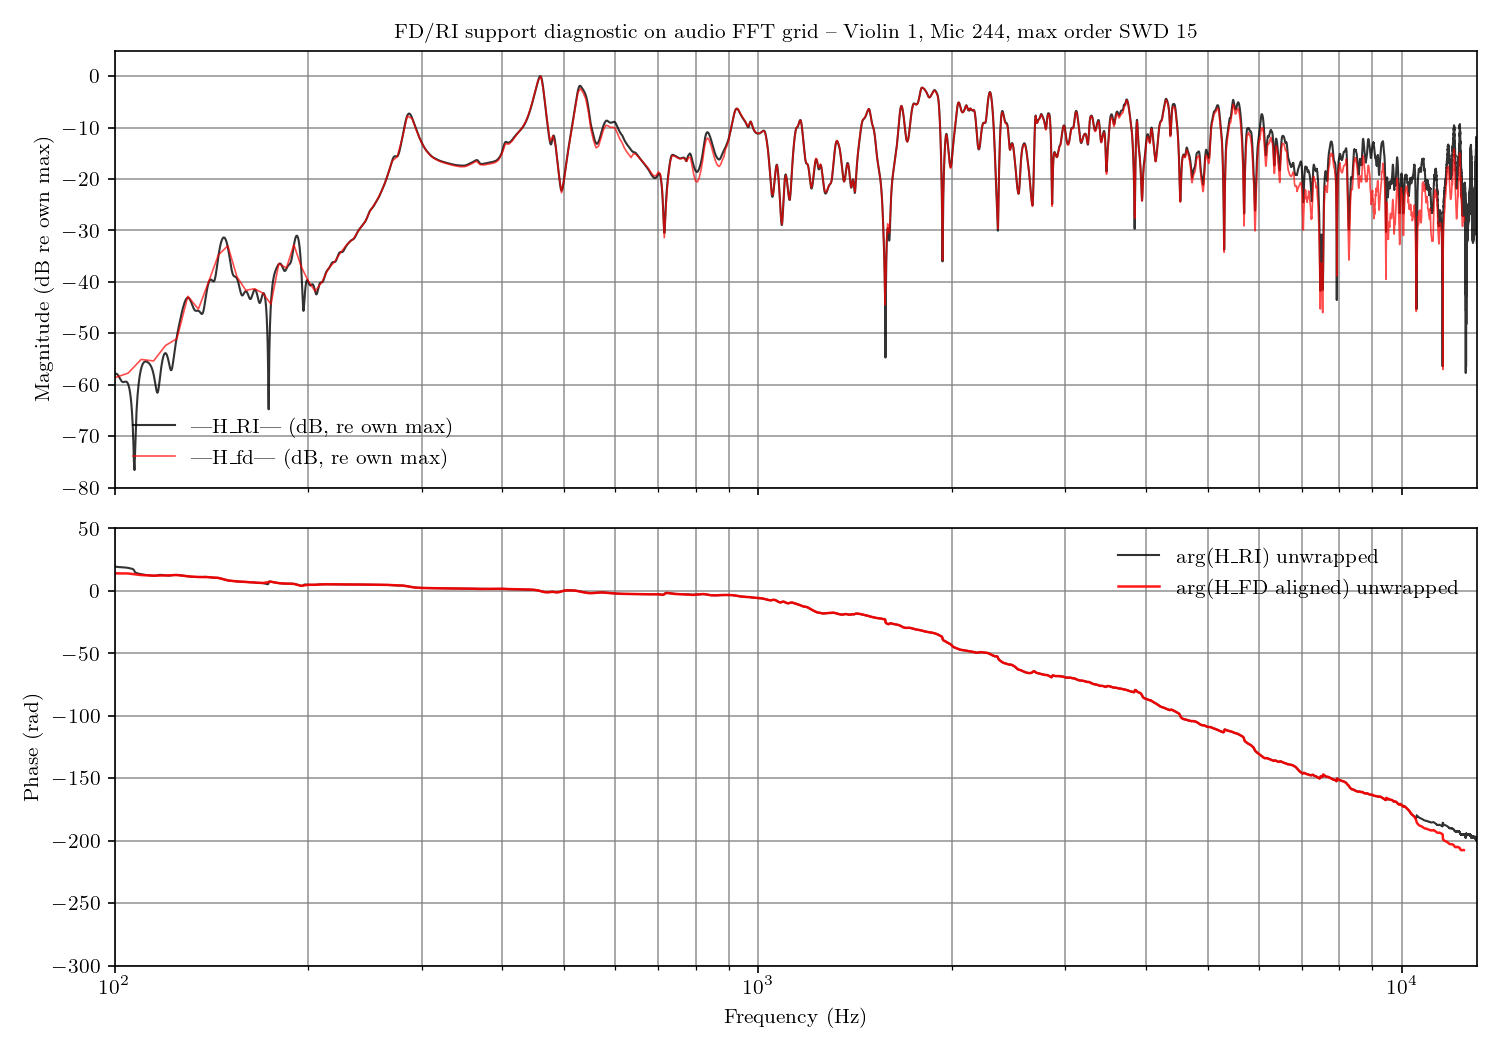

In [13]:
# Audio comparison: source log-sweep, through RI, and through corresponding FD
# Choose one of the 5 selected microphones from previous cell (0..4)
sel_k = 0
mic_idx = int(sel_idx[sel_k])

# Use the same sampling rate as measured RI for a fair comparison
fs_audio = int(Fs_RI)
dur_audio_s = 5.0
f_start = 100.0

# Keep sweep inside FD support and away from Nyquist
f_fd_max = float(frq[-1])
f_stop = min(0.45 * fs_audio, 0.98 * f_fd_max)
t_audio = np.arange(int(fs_audio * dur_audio_s)) / fs_audio

# Exponential chirp phase for a true log-frequency sweep
k_log = dur_audio_s / np.log(f_stop / f_start)
phase_log = 2 * np.pi * f_start * k_log * (np.exp(t_audio / k_log) - 1.0)
x_src = np.sin(phase_log)

# Short fade in/out to avoid clicks
fade_s = 0.02
n_fade = max(1, int(fade_s * fs_audio))
fade_in = np.linspace(0.0, 1.0, n_fade)
fade_out = np.linspace(1.0, 0.0, n_fade)
x_src[:n_fade] *= fade_in
x_src[-n_fade:] *= fade_out

# Corresponding RI at selected mic
h_ri = np.asarray(RIs[viol_idx, :, mic_idx], dtype=float)
# Convolution with RI
try:
    from scipy.signal import fftconvolve
    y_ri = fftconvolve(x_src, h_ri, mode='full')[:x_src.size]
except Exception:
    y_ri = np.convolve(x_src, h_ri, mode='full')[:x_src.size]

# -- Definition of f_fft and phase_floor_db --
f_fft = np.fft.rfftfreq(x_src.size, d=1.0/fs_audio)
phase_floor_db = -90.0

# FD transfer at this mic (on physical 'frq' grid)
H_fd = np.asarray(Hfd[viol_idx, mic_idx, :], dtype=np.complex128)

# RI transfer on the same FFT grid for direct visual comparison
h_ri_fft = np.zeros(x_src.size, dtype=float)
n_ri = min(h_ri.size, x_src.size)
h_ri_fft[:n_ri] = h_ri[:n_ri]
H_ri = np.fft.rfft(h_ri_fft)

# Helper function to unwrap phase outwards from a specific index (e.g. peak magnitude)
def unwrap_from(phase, index):
    res = np.empty_like(phase)
    res[index:] = np.unwrap(phase[index:])
    if index > 0:
        res[:index+1] = np.unwrap(phase[:index+1][::-1])[::-1]
    return res

# Unwrapped phases on the original grids outwards from peak magnitude
max_idx_ri = np.argmax(np.abs(H_ri))
max_idx_fd = np.argmax(np.abs(H_fd))

phase_ri_full = unwrap_from(np.angle(H_ri), max_idx_ri)
phase_fd_full = unwrap_from(np.angle(H_fd), max_idx_fd)

# Interpolate H_fd to the FFT frequency grid to compute a correct impulse response
# Interpolating magnitude and unwrapped phase prevents cartesian interpolation artifacts
H_fd_fft = np.zeros_like(f_fft, dtype=np.complex128)
valid_interp = (f_fft >= frq[0]) & (f_fft <= frq[-1])
mag_fd_interp = np.interp(f_fft[valid_interp], frq, np.abs(H_fd))
phase_fd_interp = np.interp(f_fft[valid_interp], frq, phase_fd_full)
H_fd_fft[valid_interp] = mag_fd_interp * np.exp(1j * phase_fd_interp)

h_fd = np.fft.irfft(H_fd_fft, n=len(x_src))

try:
    y_fd = fftconvolve(x_src, h_fd, mode='full')[:x_src.size]
except Exception:
    y_fd = np.convolve(x_src, h_fd, mode='full')[:x_src.size]

# Shared normalization for safe playback
peak = max(np.max(np.abs(x_src)), np.max(np.abs(y_ri)), np.max(np.abs(y_fd)), 1e-12)
x_play = 0.95 * x_src / peak
y_ri_play = 0.95 * y_ri / peak
y_fd_play = 0.95 * y_fd / peak

print(f"Selected mic among 5: k={sel_k}, mic index={mic_idx}")
print(f"Sweep: {f_start:.0f} Hz -> {f_stop:.0f} Hz, {dur_audio_s:.1f} s, fs={fs_audio} Hz")

mag_ri_db = 20 * np.log10(np.maximum(np.abs(H_ri), 1e-14))
mag_fd_db = 20 * np.log10(np.maximum(np.abs(H_fd), 1e-14))

mag_ri_db -= np.max(mag_ri_db)
mag_fd_db -= np.max(mag_fd_db)

# Phase diagnostic: unwrap where magnitude is sufficiently above noise floor
valid_ri = mag_ri_db > phase_floor_db
valid_fd = mag_fd_db > phase_floor_db
ix1k_ri = np.searchsorted(f_fft, 1000.0)
ix1k_fd = np.searchsorted(frq, 1000.0)

phase_ri = phase_ri_full
phase_fd = phase_fd_full-phase_fd_full[ix1k_fd] + phase_ri_full[ix1k_ri]

#H_fd *= np.exp(1j * (phase_ri_full[ix1k_ri] - phase_fd_full[ix1k_fd]))

phase_ri_plot = np.full_like(phase_ri, np.nan, dtype=float)
phase_fd_plot = np.full_like(phase_fd, np.nan, dtype=float)
phase_ri_plot[valid_ri] = phase_ri[valid_ri]
phase_fd_plot[valid_fd] = phase_fd[valid_fd]

fig_diag, (ax1, axp) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(f_fft, mag_ri_db, lw=1.0, color='k', alpha=0.8, label='|H_RI| (dB, re own max)')
ax1.plot(frq, mag_fd_db, lw=0.8, color='red', alpha=0.7, label='|H_fd| (dB, re own max)')
ax1.set_xscale('log')
ax1.set_xlim(100, min(fs_audio / 2, f_fd_max * 1.05))
ax1.set_ylim(-80, 5)
ax1.set_ylabel('Magnitude (dB re own max)')
ax1.grid(True, which='major', color='gray', alpha=0.8)
ax1.grid(True, which='minor', color='gray', alpha=0.8)

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='lower left', frameon=False)
ax1.set_title(f'FD/RI support diagnostic on audio FFT grid -- Violin {NumViolon[viol_idx]}, Mic {mic_idx}, max order SWD {N_SH}')

axp.plot(f_fft, phase_ri_plot, lw=1.0, color='k', alpha=0.8, label='arg(H_RI) unwrapped')
axp.plot(frq, phase_fd_plot, lw=1.2, color='red', alpha=0.9, label='arg(H_FD aligned) unwrapped')
axp.set_xlim(100, min(fs_audio / 2, f_fd_max * 1.05))
axp.set_ylim(-300, 50)
axp.set_xlabel('Frequency (Hz)')
axp.set_ylabel('Phase (rad)')
axp.grid(True, which='major', color='gray', alpha=0.8)
axp.grid(True, which='minor', color='gray', alpha=0.8)
axp.legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()

In [14]:
try:
    from scipy.signal import fftconvolve
    # We use h_fd which is now correctly aligned and mapped to the time domain grid
    y_fd = fftconvolve(x_src, h_fd, mode='full')[:x_src.size]
except Exception:
    y_fd = np.convolve(x_src, h_fd, mode='full')[:x_src.size]

peak = max(np.max(np.abs(x_src)), np.max(np.abs(y_ri)), np.max(np.abs(y_fd)), 1e-12)
y_fd_play = 0.95 * y_fd / peak


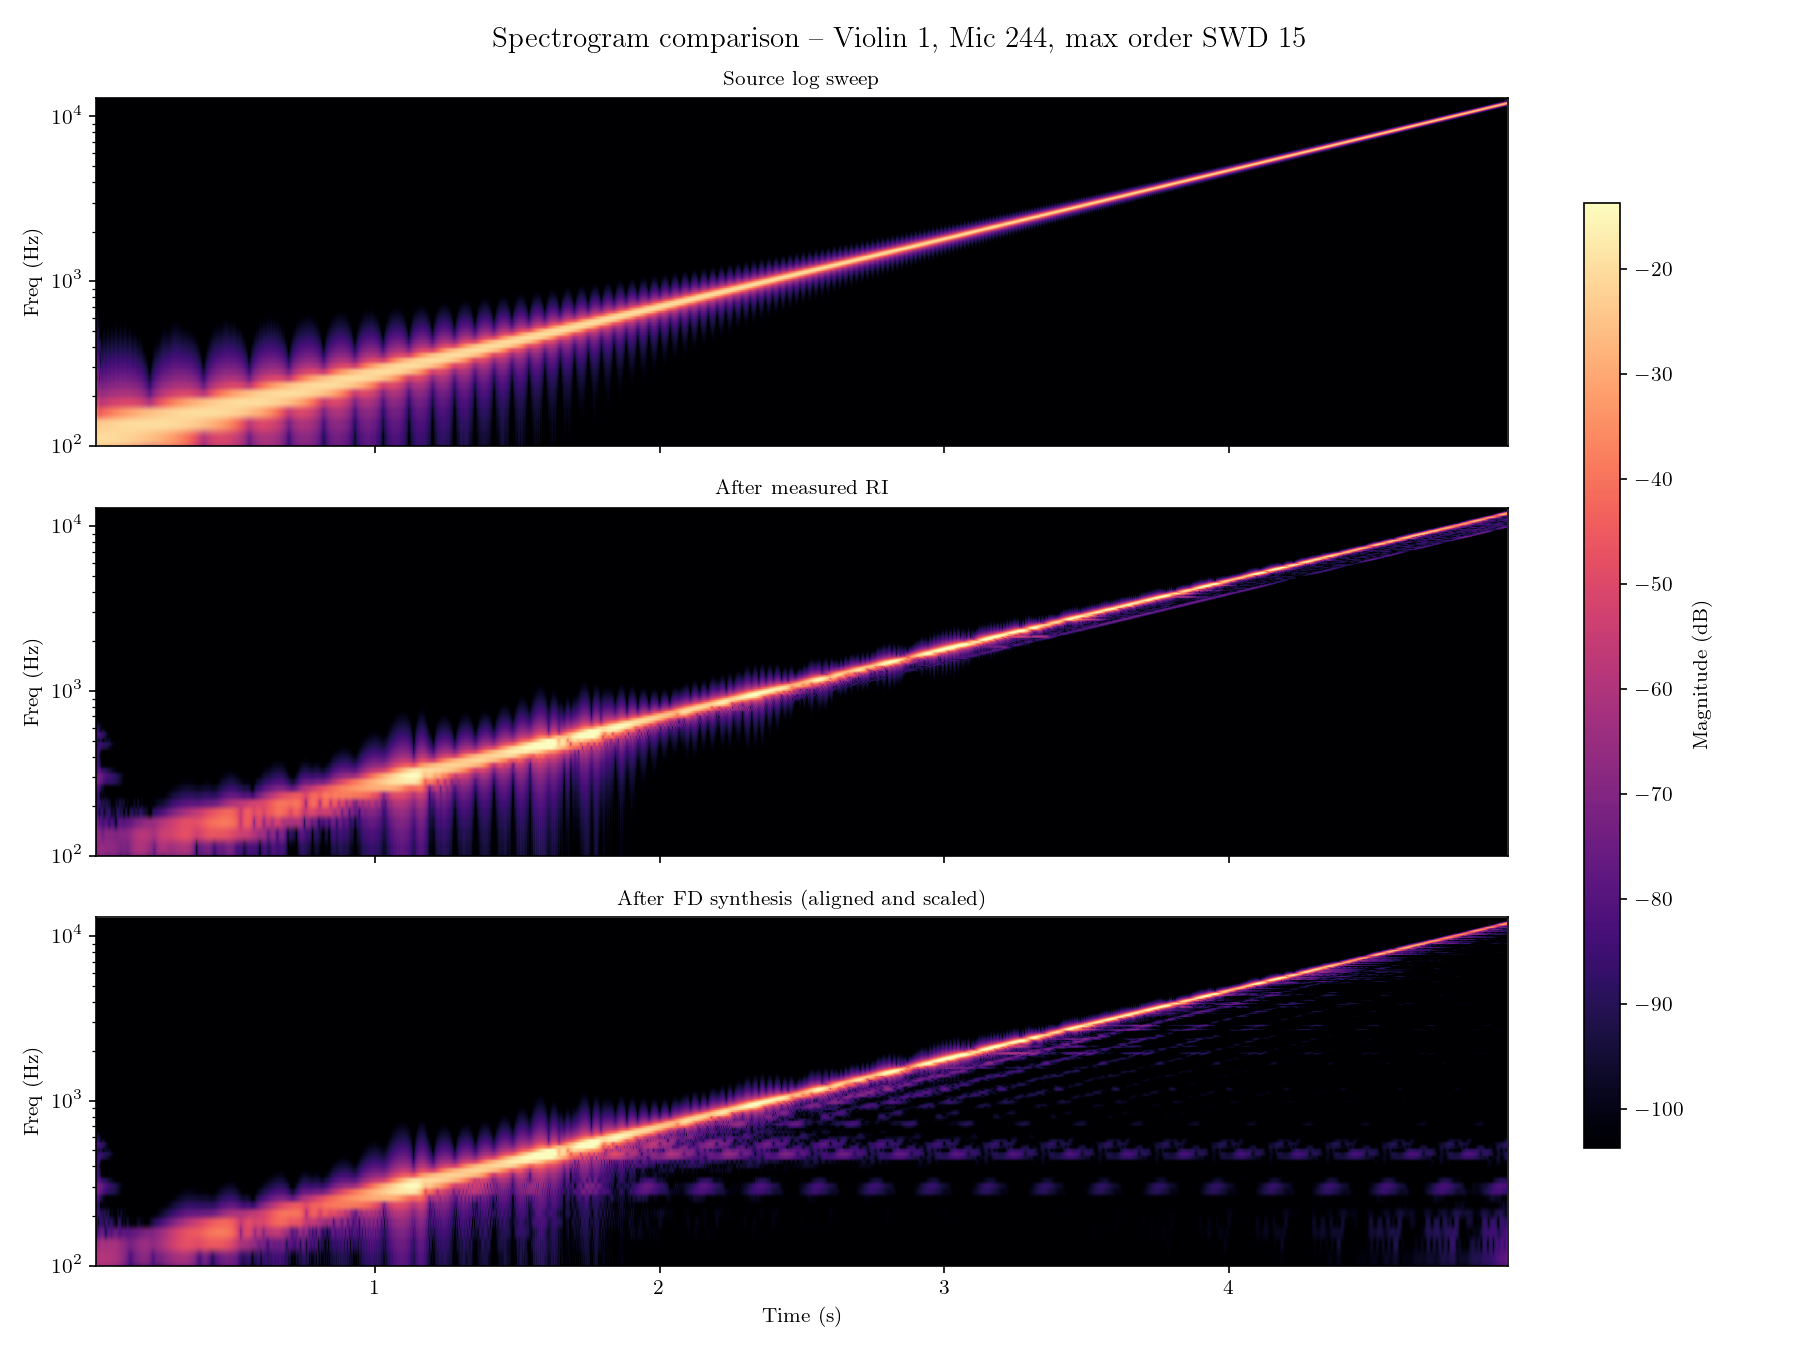

In [ ]:
# log sweep Spectrogram comparison
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"Spectrogram comparison -- Violin {NumViolon[viol_idx]}, Mic {mic_idx}, max order SWD {N_SH}", fontsize=14)

signals = [x_play, y_ri_play, y_fd_play]
titles = [
    'Source log sweep',
    'After measured RI',
    'After FD synthesis (aligned and scaled)'
]

vmax = 20 * np.log10(np.max(np.abs(x_play)) + 1e-12)
for ax, sig, title in zip(axs, signals, titles):
    Pxx, freqs_sp, bins_sp, im = ax.specgram(
        sig,
        NFFT=2048,
        Fs=fs_audio,
        noverlap=1536,
        cmap='magma',
        scale='dB',
        mode='magnitude',
        vmin=vmax - DyndB,
        vmax=vmax
    )
    ax.set_yscale('log')
    ax.set_ylim(100, min(13_000, fs_audio / 2))
    ax.set_ylabel('Freq (Hz)')
    ax.set_title(title)

axs[-1].set_xlabel('Time (s)')

fig.subplots_adjust(right=0.85, top=0.92)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Magnitude (dB)')
fig.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()